# **Lecture 22: Applications in Astrophysics - N-Body Simulations**

**Unit:** 4 (Applications in Astrophysics)

**Topic:** Gravity, Equations of Motion, and the Realistic 2-Body Problem

---

## **1. The Philosophy of N-Body Simulations**

An N-body simulation is a numerical approximation of the evolution of a system of bodies (like stars, planets, or dark matter particles) that interact with each other through a physical force—usually gravity.

While we can solve the 2-Body problem exactly using Kepler's laws and analytical algebra, the **3-Body problem (and anything $N > 2$) has no general exact analytical solution** (a fact proven by Henri Poincaré in 1887). To predict the future of the Solar System, a star cluster, or a colliding galaxy, we *must* use computers to integrate the equations of motion step-by-step.


## **2. The Equations of Motion**

Newton's Law of Universal Gravitation states that the force exerted on body $i$ by body $j$ is:
$$\vec{F}_{ij} = G \frac{m_i m_j}{|\vec{r}_{ij}|^3} \vec{r}_{ij}$$

Where $\vec{r}_{ij} = \vec{r}_j - \vec{r}_i$ is the vector pointing from body $i$ to body $j$.

Using Newton's Second Law ($\vec{F} = m\vec{a}$), the acceleration of body $i$ due to the gravitational pull of *all* other $(N-1)$ bodies in the system is:
$$\frac{d^2\vec{r}_i}{dt^2} = \sum_{j \neq i}^{N} G \frac{m_j}{|\vec{r}_j - \vec{r}_i|^3} (\vec{r}_j - \vec{r}_i)$$

This is a **System of 2nd-Order Ordinary Differential Equations (ODEs)**. Just as we did for the Wave Equation and the Simple Harmonic Oscillator, we must break this down into a system of 1st-Order ODEs to feed it into a Python solver.

## **3. The Secret Weapon: Astronomical Units (Normalization)**

If we simulate the Earth and Sun in SI units, we have to deal with:
* $G = 6.67 \times 10^{-11}$
* $M_{sun} = 2.0 \times 10^{30}$ kg
* $r = 1.5 \times 10^{11}$ m

Multiplying $10^{-11}$ by $10^{30}$ and dividing by $(10^{11})^2$ creates massive **floating-point truncation and round-off errors** (as discussed in Lecture 11). 

**The Professional Solution:** We change our units.
* **Mass:** Solar Masses ($M_\odot$) $\implies M_{sun} = 1.0$
* **Distance:** Astronomical Units (AU) $\implies r_{earth} = 1.0$
* **Time:** Years (yr) $\implies P_{earth} = 1.0$

If we plug these units into Kepler's Third Law ($P^2 = \frac{4\pi^2}{GM} a^3$), we get:
$$1^2 = \frac{4\pi^2}{G \cdot 1} 1^3 \implies \mathbf{G = 4\pi^2}$$

By using $G = 4\pi^2$, all our numbers stay between $0$ and $10$, keeping our computational precision absolutely perfect!

## **4. Python Implementation: The Realistic Earth-Sun Model**
Let's write a vectorized 2-Body simulator using `scipy.integrate.solve_ivp`.

Integrating orbital equations...
Simulation complete!


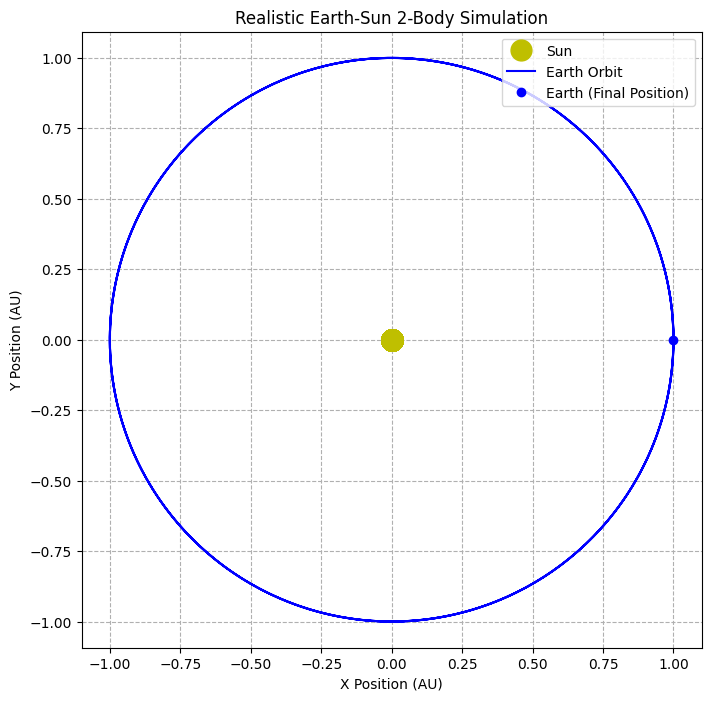

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

# 1. Physical Constants (in Astronomical Units)
G = 4 * np.pi**2
M_sun = 1.0
M_earth = 3.003e-6  # Earth is approx 3 millionths of a Solar Mass

# 2. The Method of Lines (Derivatives Function)
def two_body_equations(t, y):
    """
    State vector y contains 8 variables:
    [x_sun, y_sun, x_earth, y_earth, vx_sun, vy_sun, vx_earth, vy_earth]
    """
    x1, y1, x2, y2, vx1, vy1, vx2, vy2 = y
    
    # Distance between Sun (1) and Earth (2)
    dx = x2 - x1
    dy = y2 - y1
    r_cubed = (dx**2 + dy**2)**1.5
    
    # Derivatives of position are just the velocities
    dx1_dt = vx1
    dy1_dt = vy1
    dx2_dt = vx2
    dy2_dt = vy2
    
    # Derivatives of velocities are the gravitational accelerations
    # Acceleration of Sun (pulled by Earth)
    dvx1_dt = G * M_earth * dx / r_cubed
    dvy1_dt = G * M_earth * dy / r_cubed
    
    # Acceleration of Earth (pulled by Sun)
    dvx2_dt = -G * M_sun * dx / r_cubed
    dvy2_dt = -G * M_sun * dy / r_cubed
    
    return [dx1_dt, dy1_dt, dx2_dt, dy2_dt, dvx1_dt, dvy1_dt, dvx2_dt, dvy2_dt]

# 3. Initial Conditions
# Sun at rest at the origin
sun_pos = [0.0, 0.0]
sun_vel = [0.0, 0.0]

# Earth at 1 AU on the x-axis
earth_pos = [1.0, 0.0]
# To maintain a circular orbit, v = sqrt(GM/r). Since G=4pi^2, M=1, r=1, v = 2*pi.
# It moves purely in the y-direction initially.
earth_vel = [0.0, 2 * np.pi] 

# Combine into single state vector y0
y0 = sun_pos + earth_pos + sun_vel + earth_vel

# 4. Run the Simulation
t_span = (0, 3.0) # Simulate for 3 Earth Years
t_eval = np.linspace(0, 3.0, 1000) # 1000 data points for smooth plotting

print("Integrating orbital equations...")
solution = solve_ivp(two_body_equations, t_span, y0, method='RK45', t_eval=t_eval, rtol=1e-8, atol=1e-8)
print("Simulation complete!")

# 5. Data Extraction and Visualization
x_sun, y_sun, x_earth, y_earth = solution.y[0], solution.y[1], solution.y[2], solution.y[3]

plt.figure(figsize=(8, 8))
plt.plot(x_sun, y_sun, 'yo', markersize=15, label="Sun")
plt.plot(x_earth, y_earth, 'b-', label="Earth Orbit")
plt.plot(x_earth[-1], y_earth[-1], 'bo', markersize=6, label="Earth (Final Position)")

plt.title("Realistic Earth-Sun 2-Body Simulation")
plt.xlabel("X Position (AU)")
plt.ylabel("Y Position (AU)")
plt.legend(loc='upper right')
plt.grid(True, linestyle='--')
plt.axis('equal') # Ensure the circle doesn't look like an ellipse due to screen stretching
plt.show()


## **5. Student Exercises**

### **Exercise 1: The Heavy Jupiter Perturbation (The 3-Body Problem)**
Our current simulation solves the exact 2-Body problem. Now, let's make it a 3-Body problem by adding a gas giant.

**Task:** 
1. Modify the state vector `y` to hold 12 variables (positions and velocities for Sun, Earth, and Jupiter).
2. Add Jupiter's mass ($M_{jup} \approx 0.001 M_\odot$).
3. Place Jupiter at 5.2 AU on the x-axis, with an initial circular velocity of $v = \sqrt{G M_\odot / 5.2}$ in the y-direction.
4. Update the gravitational acceleration formulas. The Earth is now pulled by BOTH the Sun and Jupiter. Jupiter is pulled by the Sun and the Earth. 
5. Run the simulation for 12 years (one full Jupiter orbit). Does the Earth's orbit remain perfectly circular? Plot the results to see the perturbation.

---

### **Exercise 2: Euler's Catastrophe (Energy Conservation)**
In the `solve_ivp` function above, we used `method='RK45'`. This is a highly accurate Runge-Kutta solver. 

If we instead used a simple first-order **Euler Method** (like we did in Lecture 13), the Earth would slowly spiral into the Sun or fly away into space, even with tiny time steps. This is because Euler and standard RK4 are not **Symplectic**—they do not strictly conserve the geometric phase space (energy and angular momentum) of the system over long periods.

In the next lecture, we will build a custom **Leapfrog Integrator**—a symplectic algorithm specifically designed for N-Body orbital mechanics that perfectly conserves energy over billions of years.

Integrating 3-body orbital equations...
Simulation complete!


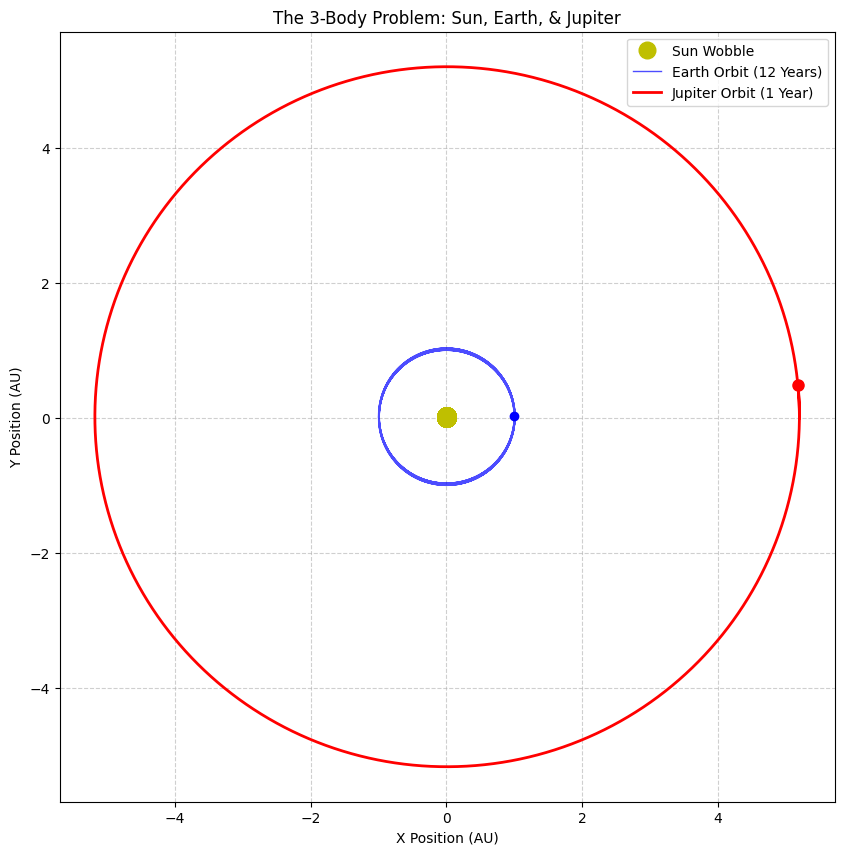

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

# 1. Physical Constants (in Astronomical Units)
G = 4 * np.pi**2
M_sun = 1.0
M_earth = 3.003e-6  
M_jup = 0.001       # Jupiter is approx 1/1000th of a solar mass

# 2. The 3-Body Equations of Motion
def three_body_equations(t, y):
    """
    State vector y now contains 12 variables:
    [x1, y1, x2, y2, x3, y3, vx1, vy1, vx2, vy2, vx3, vy3]
    Index 1: Sun, Index 2: Earth, Index 3: Jupiter
    """
    x1, y1, x2, y2, x3, y3, vx1, vy1, vx2, vy2, vx3, vy3 = y
    
    # Distance components between bodies
    dx12 = x2 - x1
    dy12 = y2 - y1
    r12_cubed = (dx12**2 + dy12**2)**1.5  # Sun to Earth
    
    dx13 = x3 - x1
    dy13 = y3 - y1
    r13_cubed = (dx13**2 + dy13**2)**1.5  # Sun to Jupiter
    
    dx23 = x3 - x2
    dy23 = y3 - y2
    r23_cubed = (dx23**2 + dy23**2)**1.5  # Earth to Jupiter
    
    # Position derivatives (velocities)
    dx1_dt, dy1_dt = vx1, vy1
    dx2_dt, dy2_dt = vx2, vy2
    dx3_dt, dy3_dt = vx3, vy3
    
    # Velocity derivatives (accelerations via Newton's Law of Gravity)
    # Sun is pulled by Earth AND Jupiter
    dvx1_dt = G * M_earth * dx12 / r12_cubed + G * M_jup * dx13 / r13_cubed
    dvy1_dt = G * M_earth * dy12 / r12_cubed + G * M_jup * dy13 / r13_cubed
    
    # Earth is pulled by Sun AND Jupiter
    dvx2_dt = -G * M_sun * dx12 / r12_cubed + G * M_jup * dx23 / r23_cubed
    dvy2_dt = -G * M_sun * dy12 / r12_cubed + G * M_jup * dy23 / r23_cubed
    
    # Jupiter is pulled by Sun AND Earth
    dvx3_dt = -G * M_sun * dx13 / r13_cubed - G * M_earth * dx23 / r23_cubed
    dvy3_dt = -G * M_sun * dy13 / r13_cubed - G * M_earth * dy23 / r23_cubed
    
    return [dx1_dt, dy1_dt, dx2_dt, dy2_dt, dx3_dt, dy3_dt, 
            dvx1_dt, dvy1_dt, dvx2_dt, dvy2_dt, dvx3_dt, dvy3_dt]

# 3. Initial Conditions
sun_pos = [0.0, 0.0]
sun_vel = [0.0, 0.0]

earth_pos = [1.0, 0.0]
earth_vel = [0.0, 2 * np.pi] 

# Jupiter at 5.2 AU. Circular velocity v = sqrt(GM/r)
jup_pos = [5.2, 0.0]
jup_vel = [0.0, np.sqrt(G * M_sun / 5.2)]

# Combine into a single state vector y0
y0 = sun_pos + earth_pos + jup_pos + sun_vel + earth_vel + jup_vel

# 4. Run the Simulation for 12 Years
t_span = (0, 12.0) 
t_eval = np.linspace(0, 12.0, 5000) # Increased resolution for 12 years

print("Integrating 3-body orbital equations...")
solution = solve_ivp(three_body_equations, t_span, y0, method='RK45', t_eval=t_eval, rtol=1e-9, atol=1e-9)
print("Simulation complete!")

# 5. Extract and Visualize
x_sun, y_sun = solution.y[0], solution.y[1]
x_earth, y_earth = solution.y[2], solution.y[3]
x_jup, y_jup = solution.y[4], solution.y[5]

plt.figure(figsize=(10, 10))

# Plot orbits
plt.plot(x_sun, y_sun, 'yo', markersize=12, label="Sun Wobble")
plt.plot(x_earth, y_earth, 'b-', lw=1, alpha=0.7, label="Earth Orbit (12 Years)")
plt.plot(x_jup, y_jup, 'r-', lw=2, label="Jupiter Orbit (1 Year)")

# Plot final positions
plt.plot(x_earth[-1], y_earth[-1], 'bo', markersize=6)
plt.plot(x_jup[-1], y_jup[-1], 'ro', markersize=8)

plt.title("The 3-Body Problem: Sun, Earth, & Jupiter")
plt.xlabel("X Position (AU)")
plt.ylabel("Y Position (AU)")
plt.legend(loc='upper right')
plt.grid(True, linestyle='--', alpha=0.6)
plt.axis('equal') 
plt.show()